In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
#plt.style.use('ggplot')
plt.style.use('seaborn-v0_8-darkgrid')  
import os

## DATA

In [2]:

main_data_dir = "/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/presentation_data"

master_df = pd.DataFrame()

for filename in os.listdir(main_data_dir):
    full_dir = os.path.join(main_data_dir,filename)

    df = pd.read_csv(full_dir)
    df = df.dropna()
    df['algorithm'] = filename.split(".")[0]


    master_df = pd.concat([master_df,df], ignore_index=True)

In [3]:
master_df

,Board Size,win rate,loss rate,draw rate,algorithm
0,3.0,43.00,38.00,18.00,AlphaZero
1,4.0,20.00,13.00,70.00,AlphaZero
2,5.0,10.00,0.00,78.00,AlphaZero
3,6.0,7.00,10.00,83.00,AlphaZero
4,3.0,72.05,23.00,4.88,Q-LEARNING
5,4.0,43.99,25.00,37.55,Q-LEARNING
6,5.0,22.38,18.00,59.95,Q-LEARNING
7,6.0,13.31,12.00,75.03,Q-LEARNING
8,7.0,8.37,7.00,84.47,Q-LEARNING
9,8.0,4.67,4.00,91.05,Q-LEARNING


In [4]:
# for now ignore AlphaZero (comment this out if we want to run it)
master_df = master_df[master_df.algorithm != "AlphaZero"]

In [5]:
# average
mc_df = master_df[master_df['algorithm'] == "MC"]
sarsa_df = master_df[master_df['algorithm'] == "SARSA"]
q_learning_df = master_df[master_df['algorithm'] == "Q-LEARNING"]



In [6]:
merged_model_free = mc_df.merge(sarsa_df, on='Board Size', suffixes=('_mc', '_sarsa'))
#merged_model_free = merged_model_free.merge(q_learning_df, on='Board Size', suffixes=('', '_qlearning'))

In [7]:
#merged_model_free.merge(q_learning_df, on='Board Size', suffixes=('', '_qlearning'))

In [8]:
merged_model_free.columns

Index(['Board Size', 'win rate_mc', 'loss rate_mc', 'draw rate_mc',
       'algorithm_mc', 'win rate_sarsa', 'loss rate_sarsa', 'draw rate_sarsa',
       'algorithm_sarsa'],
      dtype='object')

In [9]:
merged_model_free

,Board Size,win rate_mc,loss rate_mc,draw rate_mc,algorithm_mc,win rate_sarsa,loss rate_sarsa,draw rate_sarsa,algorithm_sarsa
0,3.0,65.93,23.0,11.03,MC,47.69,24.0,8.71,SARSA
1,4.0,37.29,26.0,37.10,MC,33.49,25.0,41.46,SARSA
2,5.0,23.79,12.0,32.68,MC,22.60,18.0,59.06,SARSA
3,6.0,13.98,12.0,74.03,MC,13.38,12.0,75.01,SARSA
4,7.0,8.51,8.0,83.99,MC,8.29,7.0,84.39,SARSA
5,8.0,4.29,4.0,91.59,MC,4.60,4.0,91.28,SARSA
6,9.0,2.47,2.0,95.12,MC,2.41,2.0,95.21,SARSA
7,10.0,0.74,1.0,48.57,MC,1.36,1.0,97.39,SARSA


In [10]:
merged_model_free = mc_df.merge(sarsa_df, on='Board Size', suffixes=('_mc', '_sarsa'))
merged_model_free = merged_model_free.merge(q_learning_df, on='Board Size', suffixes=('', '_qlearning'))

# Rename the q-learning columns before calculating averages
merged_model_free = merged_model_free.rename(columns={'win rate': 'win rate_qlearning', 'loss rate': 'loss rate_qlearning'})

merged_model_free['win rate'] = (merged_model_free['win rate_mc'] + merged_model_free['win rate_sarsa'] + merged_model_free['win rate_qlearning']) / 3
merged_model_free['loss rate'] = (merged_model_free['loss rate_mc'] + merged_model_free['loss rate_sarsa'] + merged_model_free['loss rate_qlearning']) / 3
merged_model_free[['Board Size', 'win rate', 'loss rate']]

,Board Size,win rate,loss rate
0,3.0,61.890000,23.333333
1,4.0,38.256667,25.333333
2,5.0,22.923333,16.000000
3,6.0,13.556667,12.000000
4,7.0,8.390000,7.333333
5,8.0,4.520000,4.000000
6,9.0,2.506667,2.000000
7,10.0,1.146667,1.000000


In [11]:
merged_model_free

,Board Size,win rate_mc,loss rate_mc,draw rate_mc,algorithm_mc,win rate_sarsa,loss rate_sarsa,draw rate_sarsa,algorithm_sarsa,win rate_qlearning,loss rate_qlearning,draw rate,algorithm,win rate,loss rate
0,3.0,65.93,23.0,11.03,MC,47.69,24.0,8.71,SARSA,72.05,23.0,4.88,Q-LEARNING,61.890000,23.333333
1,4.0,37.29,26.0,37.10,MC,33.49,25.0,41.46,SARSA,43.99,25.0,37.55,Q-LEARNING,38.256667,25.333333
2,5.0,23.79,12.0,32.68,MC,22.60,18.0,59.06,SARSA,22.38,18.0,59.95,Q-LEARNING,22.923333,16.000000
3,6.0,13.98,12.0,74.03,MC,13.38,12.0,75.01,SARSA,13.31,12.0,75.03,Q-LEARNING,13.556667,12.000000
4,7.0,8.51,8.0,83.99,MC,8.29,7.0,84.39,SARSA,8.37,7.0,84.47,Q-LEARNING,8.390000,7.333333
5,8.0,4.29,4.0,91.59,MC,4.60,4.0,91.28,SARSA,4.67,4.0,91.05,Q-LEARNING,4.520000,4.000000
6,9.0,2.47,2.0,95.12,MC,2.41,2.0,95.21,SARSA,2.64,2.0,95.10,Q-LEARNING,2.506667,2.000000
7,10.0,0.74,1.0,48.57,MC,1.36,1.0,97.39,SARSA,1.34,1.0,97.34,Q-LEARNING,1.146667,1.000000


In [12]:
master_df

,Board Size,win rate,loss rate,draw rate,algorithm
4,3.0,72.05,23.00,4.88,Q-LEARNING
5,4.0,43.99,25.00,37.55,Q-LEARNING
6,5.0,22.38,18.00,59.95,Q-LEARNING
7,6.0,13.31,12.00,75.03,Q-LEARNING
8,7.0,8.37,7.00,84.47,Q-LEARNING
9,8.0,4.67,4.00,91.05,Q-LEARNING
10,9.0,2.64,2.00,95.10,Q-LEARNING
11,10.0,1.34,1.00,97.34,Q-LEARNING
12,3.0,47.69,24.00,8.71,SARSA
13,4.0,33.49,25.00,41.46,SARSA


## Win Rate vs Board Size

TEMP ALGO RENAME ONLY
TEMP ALGO RENAME ONLY
TEMP ALGO RENAME ONLY
TEMP ALGO RENAME ONLY


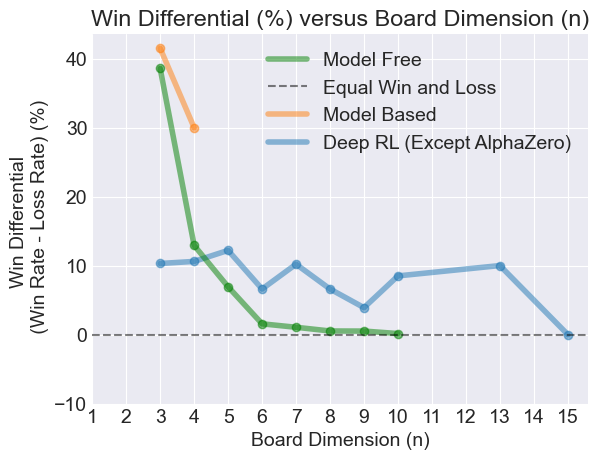

In [13]:
plt.rcParams.update({'font.size': 14})  
plt.clf()
for algo in master_df['algorithm'].unique():
    if algo not in ["MC","SARSA", "Q-LEARNING"]:
        sub_df = master_df[master_df['algorithm'] == algo]
        #temp
        print("TEMP ALGO RENAME ONLY")
        if algo == "VI":
            algo = "Model Based"
        if algo == "DQN":
            algo = "Deep RL (Except AlphaZero)"
        print("TEMP ALGO RENAME ONLY")
        #temp
        if algo == "AlphaZero":
            plt.plot(sub_df['Board Size'], sub_df['win rate'] - sub_df['loss rate'], label=algo,alpha=0.5, linewidth=4,color='magenta')
            plt.scatter(sub_df['Board Size'], sub_df['win rate'] - sub_df['loss rate'],color='magenta',alpha=0.5)
        else:
            plt.plot(sub_df['Board Size'], sub_df['win rate'] - sub_df['loss rate'], label=algo, linewidth=4,alpha=0.5)
            plt.scatter(sub_df['Board Size'], sub_df['win rate'] - sub_df['loss rate'],alpha=0.5)

plt.plot(merged_model_free['Board Size'], merged_model_free['win rate'] - merged_model_free['loss rate'], label="Model Free", color='g', linewidth=4,alpha=0.5)
plt.scatter(merged_model_free['Board Size'], merged_model_free['win rate'] - merged_model_free['loss rate'], color='g', alpha=0.5)
plt.legend()
plt.xticks(np.arange(1,16,1))
plt.ylabel("Win Differential \n (Win Rate - Loss Rate) (%)")
plt.xlabel("Board Dimension (n)")
plt.axhline(0,color='black',linestyle='--',alpha=0.5, label = "Equal Win and Loss")
plt.axis(ymin=-10)
plt.title("Win Differential (%) versus Board Dimension (n)")

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
order = [2,3,1,0]  
ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order])

plt.show()

## 4x4 to 5x5

In [14]:
master_df = master_df.sort_values(by='algorithm')
master_df_4 = master_df[master_df['Board Size'] == 4.0]
master_df_6 = master_df[master_df['Board Size'] == 6.0]

# VI msut be last in the printout below

master_df_6 = pd.concat([master_df_6, pd.DataFrame([{"Board Size":6.0, "win rate":0.0, "loss rate":0.0, "draw rate":0.0, "algorithm":"VI"}])], ignore_index=True)

In [15]:
master_df_4

,Board Size,win rate,loss rate,draw rate,algorithm
21,4.0,11.20,0.60,88.20,DQN
33,4.0,37.29,26.00,37.10,MC
5,4.0,43.99,25.00,37.55,Q-LEARNING
13,4.0,33.49,25.00,41.46,SARSA
31,4.0,32.54,2.56,64.90,VI


In [16]:
master_df_6

,Board Size,win rate,loss rate,draw rate,algorithm
0,6.0,32.00,25.4,42.60,DQN
1,6.0,13.98,12.0,74.03,MC
2,6.0,13.31,12.0,75.03,Q-LEARNING
3,6.0,13.38,12.0,75.01,SARSA
4,6.0,0.00,0.0,0.00,VI


In [17]:
def get_avg_win_rate_by_grouping(df, group, group_name):
    sub_df = df[df.algorithm.isin(group)]

    new_df = pd.DataFrame()
    new_df['win rate'] = sub_df['win rate']
    new_df['loss rate'] =  sub_df['loss rate']
    new_df['draw rate'] =  sub_df['draw rate']
    new_df['Board Size'] = df['Board Size'].iloc[0].item()

    new_df = pd.DataFrame(new_df.mean(0)).T
    new_df['algorithm'] = group_name

    return new_df
    

In [18]:
GROUP = ["SARSA", "MC", "Q-LEARNING"]
master_df_4_grouped = master_df_4.copy()
master_df_4_grouped = pd.concat([master_df_4_grouped, get_avg_win_rate_by_grouping(master_df_4, group=GROUP, group_name="Model Free")])
master_df_4_grouped = master_df_4_grouped[~master_df_4_grouped.algorithm.isin(GROUP)]

master_df_6_grouped = master_df_6.copy()
master_df_6_grouped = pd.concat([master_df_6_grouped, get_avg_win_rate_by_grouping(master_df_6, group=GROUP,group_name="Model Free")])
master_df_6_grouped = master_df_6_grouped[~master_df_6_grouped.algorithm.isin(GROUP)]

# temp rename vi since we dont have PI
master_df_4_grouped['algorithm'] = master_df_4_grouped['algorithm'].replace({"VI": "Model Based"})
master_df_6_grouped['algorithm'] = master_df_6_grouped['algorithm'].replace({"VI": "Model Based"})

master_df_4_grouped['algorithm'] = master_df_4_grouped['algorithm'].replace({"DQN": "Deep RL"})
master_df_6_grouped['algorithm'] = master_df_6_grouped['algorithm'].replace({"DQN": "Deep RL"})

##want to resort them so model based is first, then model free then DQN
master_df_4_grouped = master_df_4_grouped.iloc[[1,2,0]]
master_df_6_grouped = master_df_6_grouped.iloc[[1,2,0]]

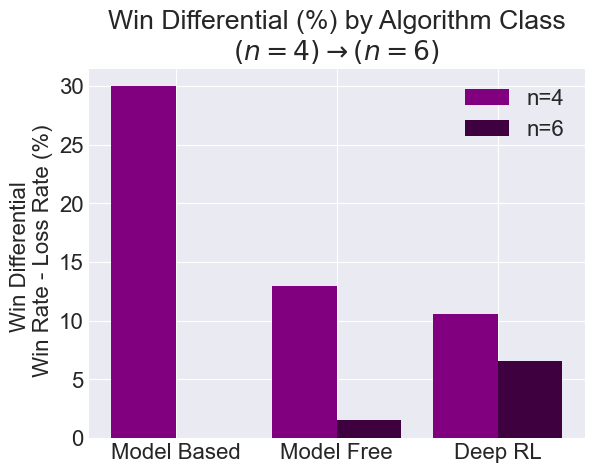

In [19]:
categories = master_df_4_grouped['algorithm'].values
#want to resort them so model based is first, then model free then DQN

v1 = master_df_4_grouped['win rate'] - master_df_4_grouped['loss rate']
v2 = master_df_6_grouped['win rate'] - master_df_6_grouped['loss rate']
w, x = 0.4, np.arange(len(categories))

plt.clf()
plt.rcParams.update({'font.size': 16})  

# this is inspired from https://www.geeksforgeeks.org/python/plotting-multiple-bar-charts-using-matplotlib-in-python/ 
plt.bar(x - w/2, v1, w, label='n=4',color='purple',alpha=1)
plt.bar(x + w/2, v2, w, label='n=6',color='#3F003F',alpha=1)

plt.xticks(x, categories)
plt.ylabel('Win Differential \n Win Rate - Loss Rate (%)')
plt.title(r'Win Differential (%) by Algorithm Class' + '\n' + r'$(n=4) \to (n=6)$')
plt.legend()
plt.show()

## N vs Draw Rate

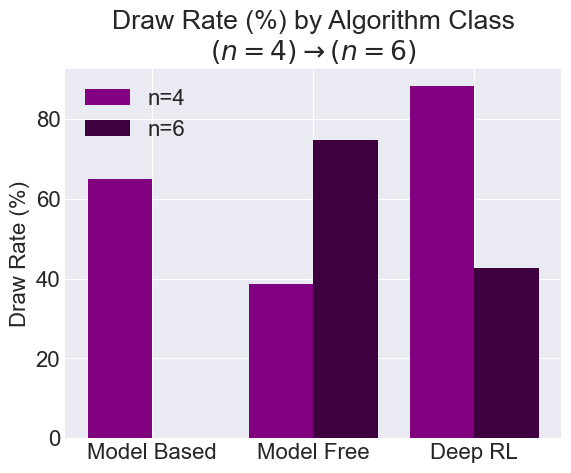

In [20]:
categories = master_df_4_grouped['algorithm'].values

v1 = master_df_4_grouped['draw rate']
v2 = master_df_6_grouped['draw rate']
w, x = 0.4, np.arange(len(categories))

plt.clf()
plt.rcParams.update({'font.size': 16})  


# this is inspired from https://www.geeksforgeeks.org/python/plotting-multiple-bar-charts-using-matplotlib-in-python/ 
plt.bar(x - w/2, v1, w, label='n=4',color='purple',alpha=1)
plt.bar(x + w/2, v2, w, label='n=6',color='#3F003F',alpha=1)


plt.xticks(x, categories)
plt.ylabel('Draw Rate (%)')
plt.title(r'Draw Rate (%) by Algorithm Class' + '\n' + r'$(n=4) \to (n=6)$')
plt.legend()
plt.show()